# SALES FORECASTING & BUSINESS INTELLIGENCE PLATFORM

## Problem Statement
Retail businesses generate large volumes of sales transactions every day, but raw transactional data alone does not provide actionable insights for business growth. Without effective data analysis, organizations face challenges in identifying sales trends, understanding customer purchasing behavior, evaluating product performance, and accurately forecasting future demand.

Inaccurate sales forecasting can lead to inventory shortages or overstocking, reduced profitability, inefficient resource allocation, and poor strategic decision-making. Additionally, the absence of interactive dashboards and business reports makes it difficult for stakeholders to monitor key performance indicators (KPIs) and respond quickly to changing market conditions.

This project aims to address these challenges by developing an end-to-end Sales Forecasting & Business Intelligence Platform that integrates Python, SQL, Machine Learning, and Power BI. The platform performs data cleaning, exploratory data analysis (EDA), business intelligence reporting, and time-series forecasting to generate meaningful insights and predict future sales. It enables businesses to make data-driven decisions, optimize inventory management, improve profitability, and enhance overall operational efficiency.

### 01_Data_Cleaning

-  <b> Data Cleaning & Preprocessing <b>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)
plt.style.use("ggplot")

- <b>Load Dataset</b>

In [18]:
df = pd.read_csv("Superstore Sales Dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


- <b> Dataset Shape </b>

In [19]:
print("DATASET SHAPE")
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

DATASET SHAPE
Rows : 9994
Columns : 21


- <b>Dataset Information</b>

In [20]:
print("DATASET INFORMATION")
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   f

- <b>Statistical Summary</b>

In [21]:
print("STATISTICAL SUMMARY")
df.describe(include="all")

STATISTICAL SUMMARY


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,49,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,09-05-2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,2001,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


- <b> Check Missing Values</b>

In [22]:
missing_values = pd.DataFrame({"Column":df.columns,"Missing Values":df.isnull().sum(),"Percentage":(df.isnull().sum()/len(df))*100})
missing_values.sort_values(by="Percentage",ascending=False)

,Column,Missing Values,Percentage
Row ID,Row ID,0,0.0
Postal Code,Postal Code,0,0.0
Discount,Discount,0,0.0
Quantity,Quantity,0,0.0
Sales,Sales,0,0.0
Product Name,Product Name,0,0.0
Sub-Category,Sub-Category,0,0.0
Category,Category,0,0.0
Product ID,Product ID,0,0.0
Region,Region,0,0.0


- <b>Visualize Missing Values</b>

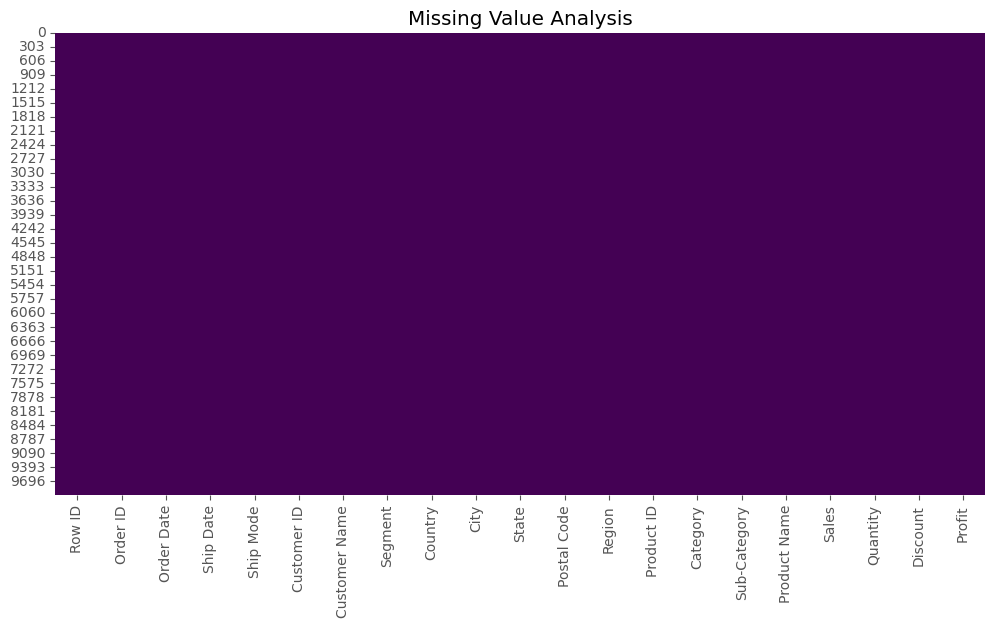

In [23]:
plt.figure(figsize=(12,6))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis")
plt.title("Missing Value Analysis")
plt.show()

- <b>Duplicate Records</b>

In [24]:
duplicates = df.duplicated().sum()
print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


- <b> Remove Duplicate Records</b>

In [25]:
df.drop_duplicates(inplace=True)
print("Duplicates Removed Successfully")

Duplicates Removed Successfully


- <b>Convert Date Columns</b>

In [27]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed"
)

- <b>Boxplot Before Removing Outliers</b>

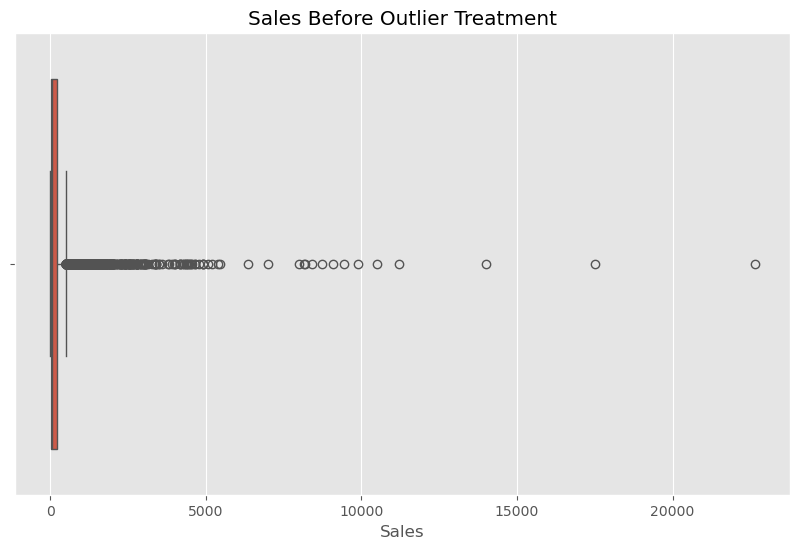

In [42]:
# ======================
# OUTLIER DETECTION
# ======================

plt.figure(figsize=(10,6))
sns.boxplot(x=df["Sales"])
plt.title("Sales Before Outlier Treatment")
plt.show()

- <b>Calculate IQR</b>

In [43]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

Lower Limit : -271.71000000000004
Upper Limit : 498.93


- <b>Count Outliers</b>

In [44]:
outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)
]

print(f"Total Outliers : {len(outliers)}")

Total Outliers : 1167


- <b>Remove Outliers</b>

In [53]:
df = df[(df["Sales"] >= lower_limit) &(df["Sales"] <= upper_limit)]

- <b>Verify After Removal</b>

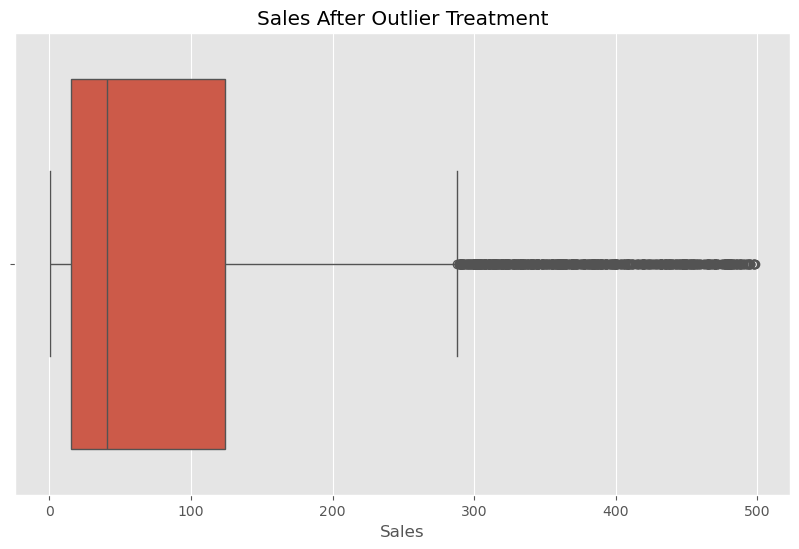

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Sales"])
plt.title("Sales After Outlier Treatment")
plt.show()

### Feature Engineering
- <b>Order Year</b>

In [28]:
df["Order Year"] = df["Order Date"].dt.year

- <b>Order Month</b>

In [29]:
df["Order Month"] = df["Order Date"].dt.month

- <b>Month Name</b>

In [30]:
df["Month Name"] = df["Order Date"].dt.month_name()

- <b>Quarter</b>

In [31]:
df["Quarter"] = df["Order Date"].dt.quarter

- <b>Day</b>

In [32]:
df["Day"] = df["Order Date"].dt.day

- <b>Day Name</b>

In [33]:
df["Day Name"] = df["Order Date"].dt.day_name()

- <b>Shipping Days</b>

In [34]:
df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

- <b>Profit Margin</b>

In [35]:
df["Profit Margin"]=(df["Profit"]/df["Sales"])*100

- <b>Check Data Types</b>

In [36]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Year                int32
Order Month               int32
Month Name               object
Quarter                   int32
Day                       int32
Day Name                 object
Shipping Days             int64
Profit Margin           float64
dtype: object

- <b>Unique Values</b>

In [38]:
categorical_columns=["Category","Sub-Category","Segment","Region"]
for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print()

Category
['Furniture' 'Office Supplies' 'Technology']

Sub-Category
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

Segment
['Consumer' 'Corporate' 'Home Office']

Region
['South' 'West' 'Central' 'East']



- <b>Final Dataset Check</b>

In [47]:
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
5       6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
6       7  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
5  Brosina Hoffman   Consumer  United States      Los Angeles  California   
6  Brosina Hoffman   Consumer  United States      Los Angeles  California   

   Postal Code Region       Product ID         Category Sub-Ca

- <b>Final Shape</b>

In [48]:
print(df.shape)

(8827, 29)


- <b>Save Clean Dataset</b>

In [49]:
df.to_csv("Superstore Sales Dataset.csv",index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


- <b>Business Summary</b>

In [50]:
print("BUSINESS SUMMARY")
print(f"Total Orders : {df['Order ID'].nunique()}")
print(f"Total Customers : {df['Customer ID'].nunique()}")
print(f"Total Revenue : {df['Sales'].sum():,.2f}")
print(f"Total Profit : {df['Profit'].sum():,.2f}")
print(f"Average Order Value : {(df['Sales'].sum()/df['Order ID'].nunique()):,.2f}")

BUSINESS SUMMARY
Total Orders : 4725
Total Customers : 790
Total Revenue : 819,718.06
Total Profit : 98,850.43
Average Order Value : 173.49


- <b>Export Summary Report</b>

In [ ]:
summary = {
    "Rows":[df.shape[0]],
    "Columns":[df.shape[1]],
    "Revenue":[df["Sales"].sum()],
    "Profit":[df["Profit"].sum()],
    "Orders":[df["Order ID"].nunique()]}
summary_df = pd.DataFrame(summary)
summary_df.to_csv("Superstore Sales Dataset_summary.csv", index=False)
print("Summary Exported Successfully")

Summary Exported Successfully
